# 2 глава. Первичный анализ набора данных с временными рядами

Набор данных: **SKAB — Skoltech Anomaly Benchmark**  
Файл: `0.csv`  
Задача: анализ многомерного временного ряда и выявление аномалий.

## 1. Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

## 2. Загрузка и первичное знакомство с данными

In [2]:
# Загрузка набора данных SKAB
url = "https://raw.githubusercontent.com/waico/SKAB/refs/heads/master/data/valve1/0.csv"

df = pd.read_csv(url, sep=';')

# Преобразование столбца datetime во временной формат
df['datetime'] = pd.to_datetime(df['datetime'])

# Сортировка по времени
df = df.sort_values('datetime')

# Установка datetime в качестве индекса
df.set_index('datetime', inplace=True)

# Просмотр первых строк
display(df.head())

# Информация о структуре данных
df.info()

# Основные статистические характеристики
display(df.describe())

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,changepoint
datetime,,,,,,,,,,
2020-03-09 10:14:33,0.026588,0.040111,1.33020,0.054711,79.3366,26.0199,233.062,32.0,0.0,0.0
2020-03-09 10:14:34,0.026170,0.040453,1.35399,0.382638,79.5158,26.0258,236.040,32.0,0.0,0.0
2020-03-09 10:14:35,0.026199,0.039419,1.54006,0.710565,79.3756,26.0265,251.380,32.0,0.0,0.0
2020-03-09 10:14:36,0.026027,0.039641,1.33458,0.382638,79.6097,26.0393,234.392,32.0,0.0,0.0
2020-03-09 10:14:37,0.026290,0.040273,1.07851,-0.273216,79.6109,26.0420,225.342,32.0,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1147 entries, 2020-03-09 10:14:33 to 2020-03-09 10:34:32
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Accelerometer1RMS    1147 non-null   float64
 1   Accelerometer2RMS    1147 non-null   float64
 2   Current              1147 non-null   float64
 3   Pressure             1147 non-null   float64
 4   Temperature          1147 non-null   float64
 5   Thermocouple         1147 non-null   float64
 6   Voltage              1147 non-null   float64
 7   Volume Flow RateRMS  1147 non-null   float64
 8   anomaly              1147 non-null   float64
 9   changepoint          1147 non-null   float64
dtypes: float64(10)
memory usage: 98.6 KB


,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,changepoint
count,1147.000000,1147.000000,1147.000000,1147.000000,1147.000000,1147.000000,1147.000000,1147.000000,1147.000000,1147.000000
mean,0.026521,0.040174,1.004630,0.084159,77.436352,25.958171,230.927635,32.022679,0.349608,0.003487
std,0.000329,0.000774,0.268688,0.249567,1.745585,0.078456,10.748393,0.457728,0.477054,0.058977
min,0.025553,0.038072,0.388229,-0.601143,74.237000,25.829900,203.967000,31.000000,0.000000,0.000000
25%,0.026293,0.039631,0.794215,0.054711,75.663000,25.878800,225.340500,32.000000,0.000000,0.000000
50%,0.026520,0.040172,1.035130,0.054711,78.383300,25.954800,231.339000,32.000000,0.000000,0.000000
75%,0.026743,0.040697,1.221525,0.382638,78.917750,26.020300,237.099500,32.000000,1.000000,0.000000
max,0.027489,0.043046,1.662610,0.710565,79.889100,26.104400,255.324000,32.998600,1.000000,1.000000


## 3. Список числовых каналов датчиков

In [3]:
# Список числовых каналов датчиков без служебных признаков anomaly и changepoint
sensor_cols = [
    'Accelerometer1RMS',
    'Accelerometer2RMS',
    'Current',
    'Pressure',
    'Temperature',
    'Thermocouple',
    'Voltage',
    'Volume Flow RateRMS'
]

## 4. Визуализация исходных данных

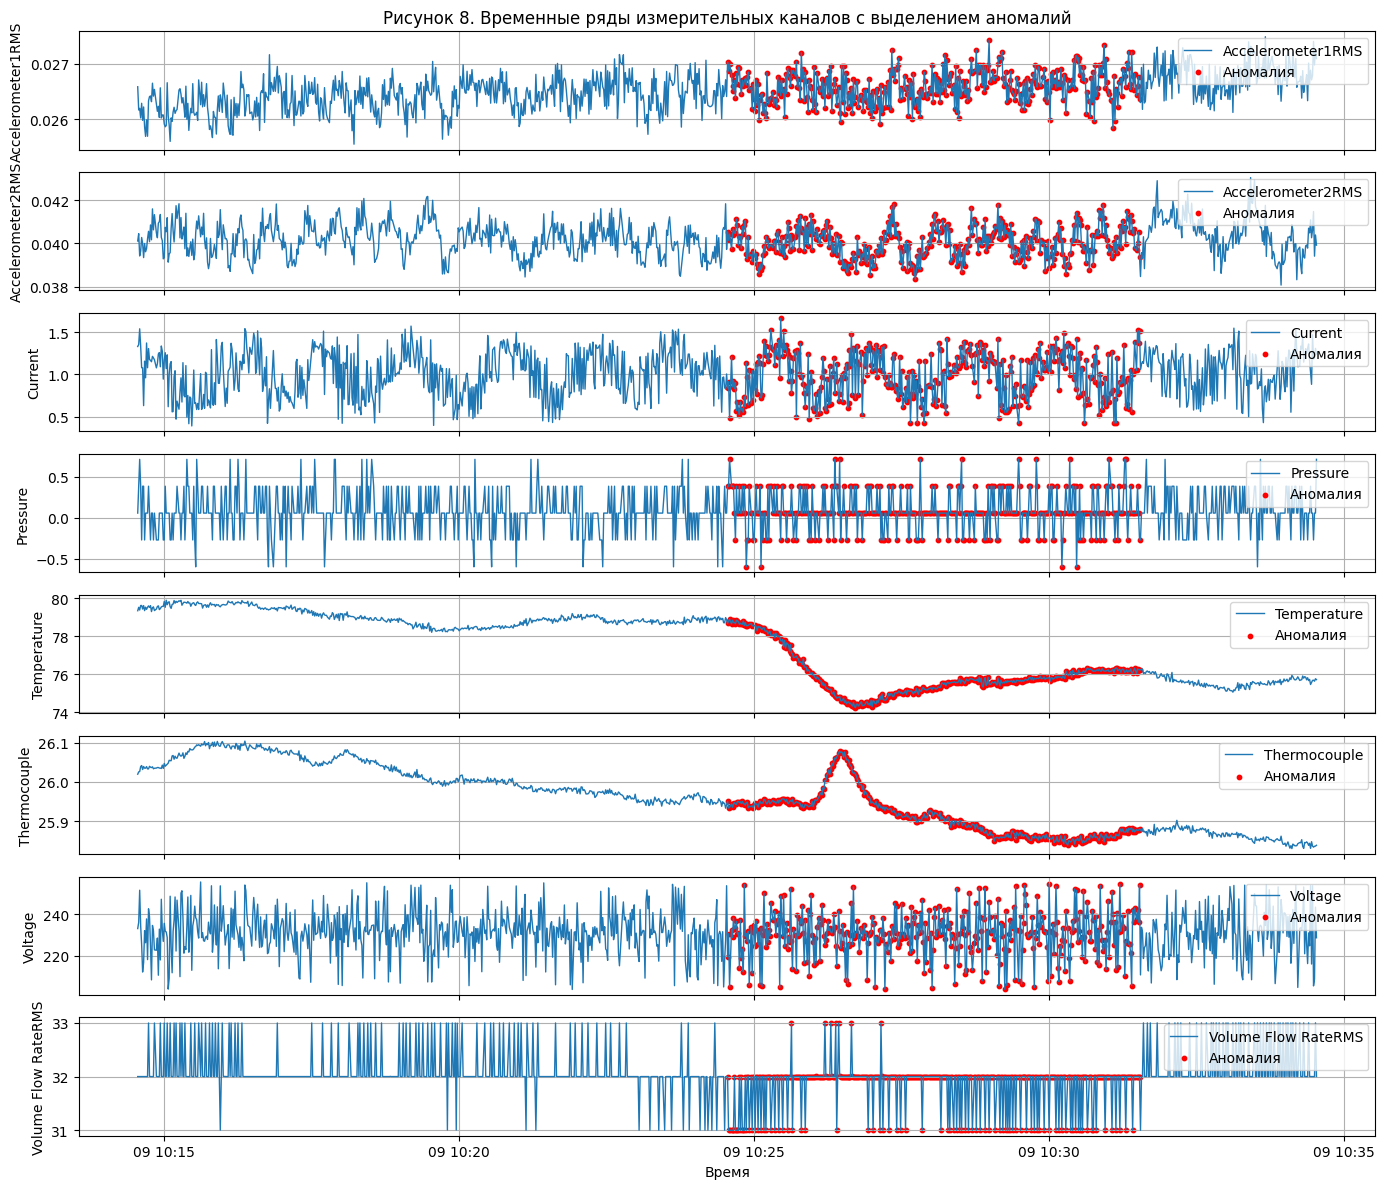

In [4]:
# Рисунок 8. Временные ряды измерительных каналов с выделением аномалий

fig, axes = plt.subplots(len(sensor_cols), 1, figsize=(14, 12), sharex=True)

anomaly_data = df[df['anomaly'] == 1]

for ax, col in zip(axes, sensor_cols):
    ax.plot(df.index, df[col], linewidth=1, label=col)

    # Выделение аномальных наблюдений красными точками
    ax.scatter(
        anomaly_data.index,
        anomaly_data[col],
        color='red',
        s=10,
        label='Аномалия'
    )

    ax.set_ylabel(col)
    ax.grid(True)
    ax.legend(loc='upper right')

axes[0].set_title('Рисунок 8. Временные ряды измерительных каналов с выделением аномалий')
axes[-1].set_xlabel('Время')

plt.tight_layout()
plt.show()

## 5. Статистический анализ

In [5]:
# Таблица 4. Основные статистические характеристики признаков

stats_table = df[sensor_cols].describe()

display(stats_table)

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS
count,1147.000000,1147.000000,1147.000000,1147.000000,1147.000000,1147.000000,1147.000000,1147.000000
mean,0.026521,0.040174,1.004630,0.084159,77.436352,25.958171,230.927635,32.022679
std,0.000329,0.000774,0.268688,0.249567,1.745585,0.078456,10.748393,0.457728
min,0.025553,0.038072,0.388229,-0.601143,74.237000,25.829900,203.967000,31.000000
25%,0.026293,0.039631,0.794215,0.054711,75.663000,25.878800,225.340500,32.000000
50%,0.026520,0.040172,1.035130,0.054711,78.383300,25.954800,231.339000,32.000000
75%,0.026743,0.040697,1.221525,0.382638,78.917750,26.020300,237.099500,32.000000
max,0.027489,0.043046,1.662610,0.710565,79.889100,26.104400,255.324000,32.998600


## 6. Проверка частоты дискретизации

In [6]:
# Проверка частоты дискретизации временного ряда

df.index = pd.to_datetime(df.index)
df = df.sort_index()

time_diff = df.index.to_series().diff().dropna()

print("Минимальный интервал:", time_diff.min())
print("Максимальный интервал:", time_diff.max())
print("Наиболее частый интервал:", time_diff.mode()[0])
print("Количество разных интервалов:")
print(time_diff.value_counts())

Минимальный интервал: 0 days 00:00:01
Максимальный интервал: 0 days 00:00:02
Наиболее частый интервал: 0 days 00:00:01
Количество разных интервалов:
datetime
0 days 00:00:01    1093
0 days 00:00:02      53
Name: count, dtype: int64


## 7. Анализ пропущенных значений

In [7]:
# Анализ пропущенных значений

missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    'Количество пропусков': missing_values,
    'Доля пропусков, %': missing_percent
})

display(missing_table)

,Количество пропусков,"Доля пропусков, %"
Accelerometer1RMS,0,0.0
Accelerometer2RMS,0,0.0
Current,0,0.0
Pressure,0,0.0
Temperature,0,0.0
Thermocouple,0,0.0
Voltage,0,0.0
Volume Flow RateRMS,0,0.0
anomaly,0,0.0
changepoint,0,0.0


## 8. Количественная оценка выбросов по правилу трёх сигм

In [8]:
# Таблица 5. Количество выбросов по правилу трёх сигм

outliers_summary = []

for col in sensor_cols:
    mean = df[col].mean()
    std = df[col].std()

    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std

    outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outliers_share = outliers_count / len(df) * 100

    outliers_summary.append({
        'Признак': col,
        'Количество выбросов': outliers_count,
        'Доля выбросов, %': round(outliers_share, 2)
    })

outliers_df = pd.DataFrame(outliers_summary)

display(outliers_df)

,Признак,Количество выбросов,"Доля выбросов, %"
0,Accelerometer1RMS,0,0.00
1,Accelerometer2RMS,3,0.26
2,Current,0,0.00
3,Pressure,0,0.00
4,Temperature,0,0.00
5,Thermocouple,0,0.00
6,Voltage,0,0.00
7,Volume Flow RateRMS,0,0.00


## 9. Диаграммы размаха числовых признаков

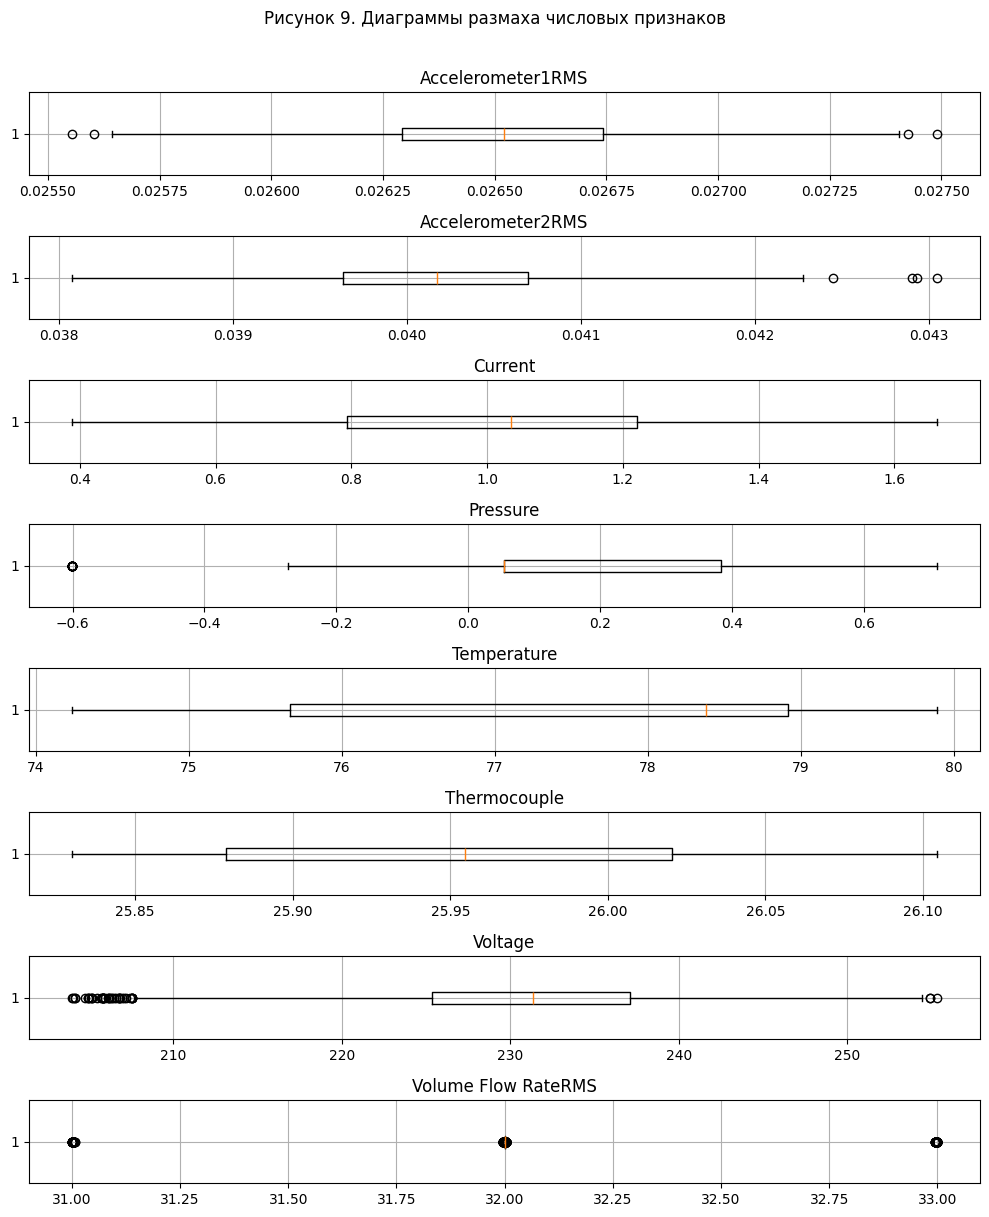

In [9]:
# Рисунок 9. Диаграммы размаха числовых признаков

fig, axes = plt.subplots(len(sensor_cols), 1, figsize=(10, 12))

for ax, col in zip(axes, sensor_cols):
    ax.boxplot(df[col], vert=False)
    ax.set_title(col)
    ax.grid(True)

fig.suptitle('Рисунок 9. Диаграммы размаха числовых признаков', y=1.01)

plt.tight_layout()
plt.show()

## 10. Анализ диапазонов значений

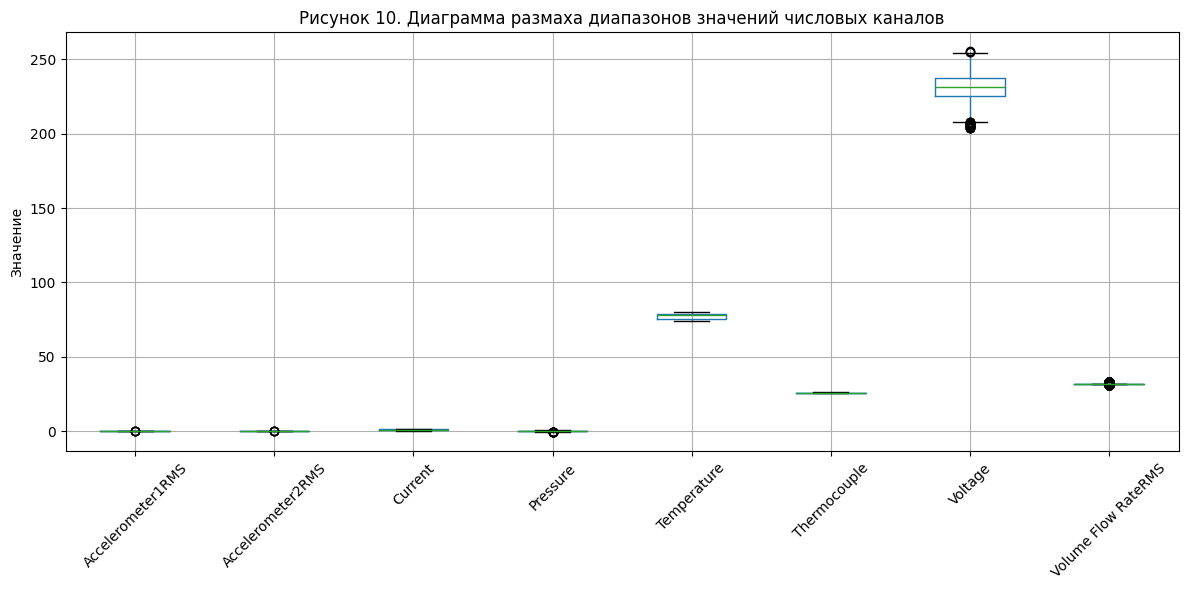

In [10]:
# Рисунок 10. Диаграмма размаха диапазонов значений числовых каналов

plt.figure(figsize=(12, 6))

df[sensor_cols].boxplot()

plt.title('Рисунок 10. Диаграмма размаха диапазонов значений числовых каналов')
plt.ylabel('Значение')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

## 11. Корреляционный анализ

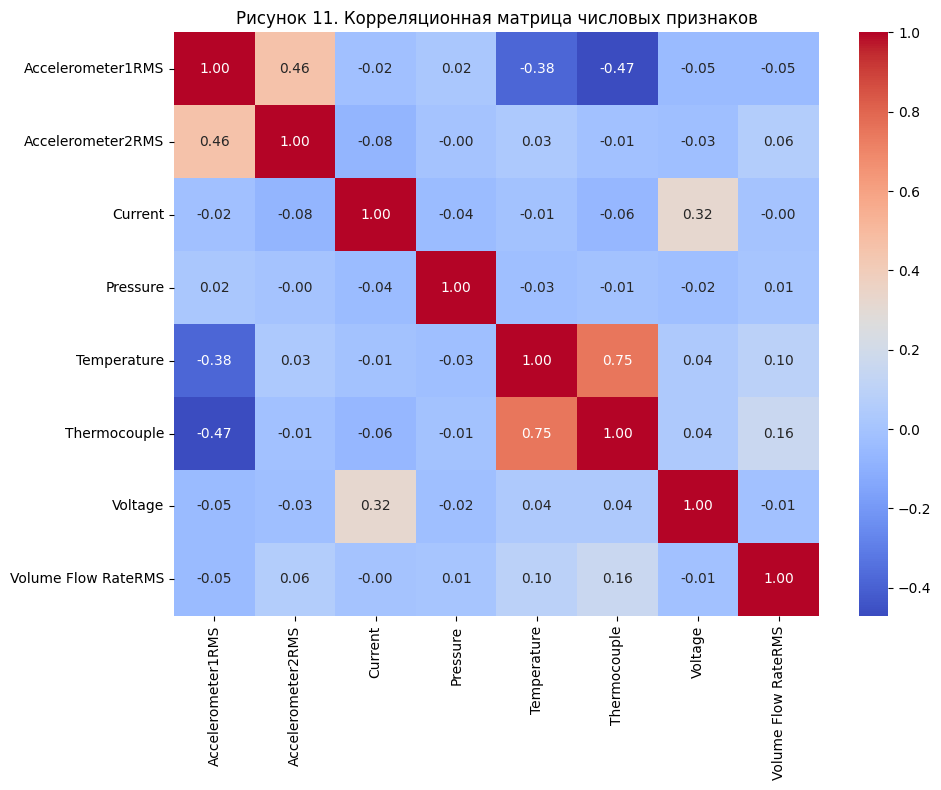

In [11]:
# Рисунок 11. Корреляционная матрица числовых признаков

corr_matrix = df[sensor_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm'
)

plt.title('Рисунок 11. Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.show()

## 12. Декомпозиция временного ряда

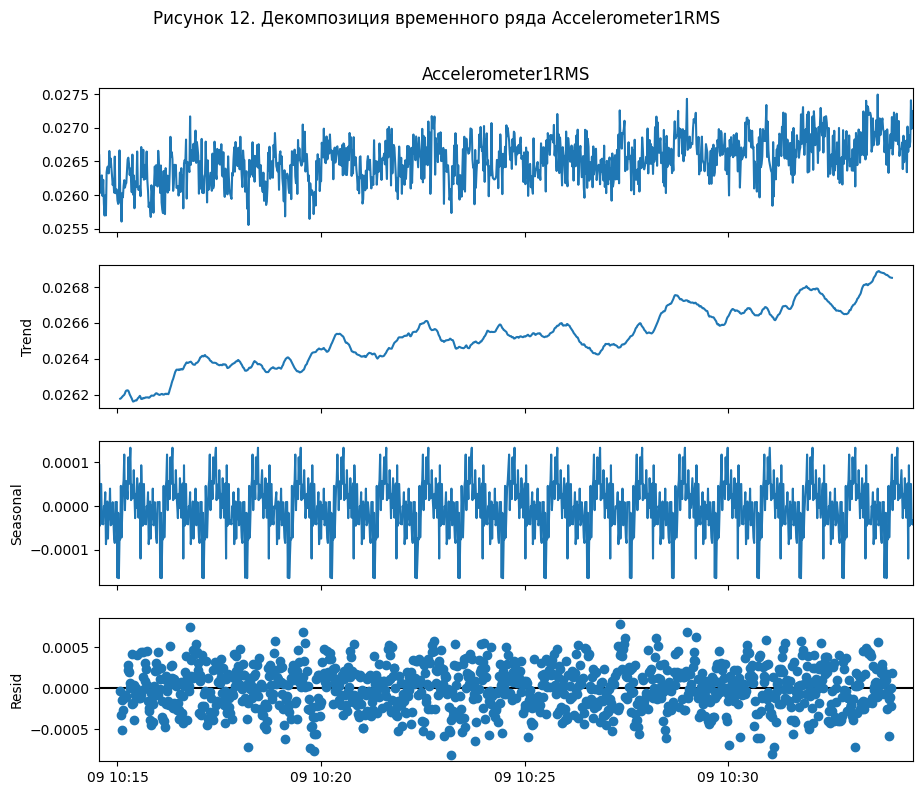

In [12]:
# Рисунок 12. Декомпозиция временного ряда Accelerometer1RMS

signal_col = 'Accelerometer1RMS'

# Выбор временного ряда
series = df[signal_col].astype(float)

# Декомпозиция временного ряда
# period=60 означает условную минутную сезонность при частоте около 1 секунды
decomposition = seasonal_decompose(
    series,
    model='additive',
    period=60
)

# Визуализация декомпозиции
fig = decomposition.plot()
fig.set_size_inches(10, 8)
fig.suptitle('Рисунок 12. Декомпозиция временного ряда Accelerometer1RMS', y=1.02)

plt.show()

## 13. Расчёт отношения сигнал/шум

In [13]:
# Расчёт отношения сигнал/шум для канала Accelerometer1RMS

trend = decomposition.trend
seasonal = decomposition.seasonal
resid = decomposition.resid

# Для аддитивной модели сигнал = тренд + сезонная компонента
signal_component = trend + seasonal

# Удаление NaN, которые появляются по краям при декомпозиции
valid_data = pd.DataFrame({
    'signal': signal_component,
    'noise': resid
}).dropna()

signal_var = valid_data['signal'].var()
noise_var = valid_data['noise'].var()

snr = 10 * np.log10(signal_var / noise_var)

print(f"SNR: {snr:.2f} дБ")

SNR: -4.03 дБ


## 14. Распределение остатков временного ряда

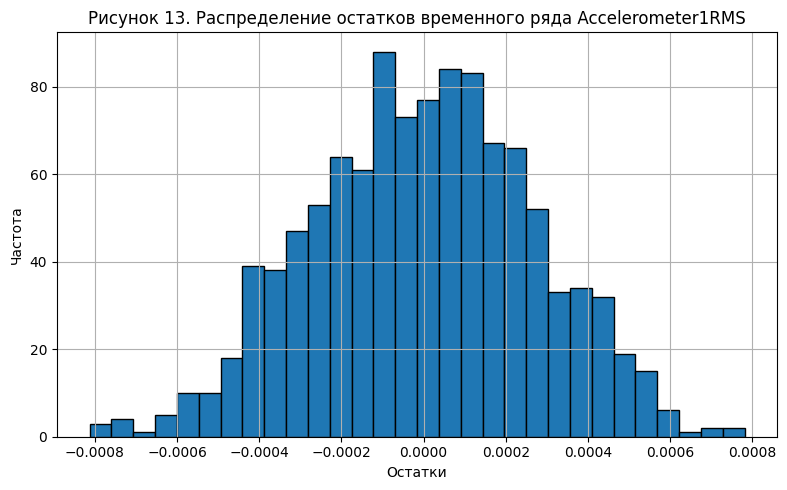

In [14]:
# Рисунок 13. Распределение остатков временного ряда Accelerometer1RMS

plt.figure(figsize=(8, 5))

plt.hist(valid_data['noise'], bins=30, edgecolor='black')

plt.title('Рисунок 13. Распределение остатков временного ряда Accelerometer1RMS')
plt.xlabel('Остатки')
plt.ylabel('Частота')
plt.grid(True)

plt.tight_layout()
plt.show()

## 15. Итог

В ноутбуке выполнены основные этапы первичного анализа временного ряда: загрузка данных, визуализация каналов, статистический анализ, проверка частоты дискретизации, анализ пропусков и выбросов, сравнение диапазонов значений, корреляционный анализ и анализ шумовой составляющей.